# Tumor Classification
Programmed by Emily Bodenbender  
Uses regularized logistic regression with a real dataset.

In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import copy
import math

## Data Preparation
The dataset comes from Wisconsin Diagnostic Breast Cancer and consists of 30 input features for each sample and a target value, M (Malignant) or B (Benign). Input features include radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension.

In [2]:
def load_data(filename):
    try:
        infile = open(filename, "r")
    except IOError:
        print("could not open file", filename)
        return -1
    
    reader = csv.reader(infile)
    data = []
    for row in reader:
        data.append(row)
    X = [row[2:] for row in data]
    y = [row[1] for row in data]
    return X, y

In [3]:
# helper function to grab a column from a table
def get_column(table, col_index):
    col = []
    for row in table:
        value = float(row[col_index])
        col.append(value)
    return col

In [4]:
# load data
X_train_tmp, y_train_str = load_data("./data/wdbc.data")
y_train = []
for val in y_train_str: # convert M, B to 1, 0
    if val == 'M':
        y_train.append(1)
    if val == 'B':
        y_train.append(0)
y_train = np.array(y_train)

### Z-Score Normalization


In [5]:
def normalize(data):
    normalized_data = []
    avg = np.average(data)
    std = np.std(data)
    for val in data:
        normalized_val = (val - avg) / std
        normalized_data.append(normalized_val)
    return normalized_data

In [6]:
# call normalize (by column) for all data in X_train
X_attributes = [] # stores each normalized column from X_train
for i in range(len(X_train_tmp[0])):
    attr_normalized = normalize(get_column(X_train_tmp, i))
    X_attributes.append(attr_normalized)
    
# take list of normalized columns and add them back to a table (X_train)
X_train = []
for i in range(len(X_attributes[0])):
    row = []
    for attr in X_attributes:
        row.append(attr[i])
    X_train.append(row)
X_train = np.array(X_train)

## Regularization

The regularized cost function for logistic regression is of the form: 

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] + \frac{\lambda}{2m}\sum_{i=0}^{n-1}w_{j}^{2}$$

where
* m is the number of training examples in the dataset


* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is - 

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$, which is the actual label

*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x^{(i)}} + b)$ where function $g$ is the sigmoid function.

In [7]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z
         
    """
    g = []
    exp_z = np.exp(z)
    if not isinstance(exp_z, float):
        for exp in exp_z:
            sig_z = (1 / (1 + (1 / exp))) # 1/exp gets e^-z rather than e^z
            g.append(sig_z)
    else:
        g.append((1 / (1 + (1 / exp_z))))
    g = np.array(g)
    
    return g

In [8]:
def compute_cost(X, y, w, b, lambda_=1):
    """
    Computes the cost over all examples
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value 
      w : (array_like Shape (n,)) Values of parameters of the model      
      b : scalar Values of bias parameter of the model
      lambda_: unused placeholder
    Returns:
      total_cost: (scalar)         cost 
    """

    m, n = X.shape
    
    total_cost = 0
    for i in range(m):
        z_wb = np.dot(X[i], w) + b
        f_wb = sigmoid(z_wb)
        loss = (-y[i] * math.log(f_wb)) - ((1 - y[i]) * math.log(1 - f_wb))
        total_cost += loss
    total_cost = total_cost / m
    # add regularization
    regularization = 0
    for i in range(n):
        regularization += w[i] ** 2
    regularization = regularization * (lambda_ / (2 * m))
    total_cost += regularization
    
    return total_cost

def compute_gradient(X, y, w, b, lambda_=1): 
    """
    Computes the gradient for logistic regression 
 
    Args:
      X : (ndarray Shape (m,n)) variable such as house size 
      y : (array_like Shape (m,1)) actual value 
      w : (array_like Shape (n,1)) values of parameters of the model      
      b : (scalar)                 value of parameter of the model 
      lambda_: unused placeholder.
    Returns
      dj_dw: (array_like Shape (n,1)) The gradient of the cost w.r.t. the parameters w. 
      dj_db: (scalar)                The gradient of the cost w.r.t. the parameter b. 
    """
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    for i in range(m):
        z_wb = np.dot(X[i], w) + b
        f_wb = sigmoid(z_wb)
        dj_db += f_wb - y[i]
        for j in range(n): # + lambda_ * w[j] adds regularization
            dj_dw[j] += ((f_wb - y[i]) * X[i][j]) + (lambda_ * w[j])
    dj_db = dj_db / m
    dj_dw = dj_dw / m
        
    return dj_db, dj_dw

## Gradient Descent With Multiple Variables
Regularized gradient descent for logistic regression:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j}   \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where n is the number of features, parameters $w_j$,  $b$ are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} + \frac{\lambda}{m}w_{j}   \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value

In [9]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X :    (array_like Shape (m, n)
      y :    (array_like Shape (m,))
      w_in : (array_like Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)                 Initial value of parameter of the model
      cost_function:                  function to compute cost
      alpha : (float)                 Learning rate
      num_iters : (int)               number of iterations to run gradient descent
      lambda_ (scalar, float)         regularization constant
      
    Returns:
      w : (array_like Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(X)
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters
        dj_db, dj_dw = compute_gradient(X, y, w_in, b_in)   

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        # Print cost at every 10th iteration or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history # return J history for graphing

In [10]:
def predict(X, w, b): 
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w
    
    Args:
    X : (ndarray Shape (m, n))
    w : (array_like Shape (n,))      Parameters of the model
    b : (scalar, float)              Parameter of the model

    Returns:
    p: (ndarray (m,1))
        The predictions for X using a threshold at 0.5
    """
    # number of training examples
    m, n = X.shape   
    p = np.zeros(m)
   
    p_lst = []
    for i in range(m):
        z_wb = np.dot(X[i], w) + b
        f_wb = sigmoid(z_wb)
        if f_wb >= 0.5:
            p_lst.append(1)
        else:
            p_lst.append(0)
    p = np.array(p_lst)
    return p

In [11]:
# initialize parameters
initial_w = np.zeros(len(X_train[0]))
initial_b = 0.
# some gradient descent settings
iterations = 10000
alpha = 1.0e-4
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations, 0)
print("b,w found by gradient descent: ", b_final, w_final)
m,_ = X_train.shape
predictions = predict(X_train, w_final, b_final)

# compute accuracy
num_correct = 0
for i in range(len(predictions)):
    if predictions[i] == y_train[i]:
        num_correct += 1
print("accuracy:", num_correct / len(predictions))

Iteration    0: Cost     0.69   
Iteration 1000: Cost     0.55   
Iteration 2000: Cost     0.47   
Iteration 3000: Cost     0.43   
Iteration 4000: Cost     0.39   
Iteration 5000: Cost     0.37   
Iteration 6000: Cost     0.36   
Iteration 7000: Cost     0.35   
Iteration 8000: Cost     0.34   
Iteration 9000: Cost     0.33   
Iteration 9999: Cost     0.32   
b,w found by gradient descent:  [-0.10266951] [ 0.10588277  0.06768012  0.10659839  0.10150327  0.04546784  0.07110528
  0.09025738  0.10774222  0.04016635 -0.01838494  0.0777749  -0.00339423
  0.07350701  0.07388507 -0.01265234  0.02040166  0.01489029  0.04301709
 -0.00822815 -0.00992428  0.11465962  0.0772799   0.11386608  0.10635731
  0.06476312  0.07754595  0.08831975  0.11291241  0.06425905  0.03941076]
accuracy: 0.945518453427065


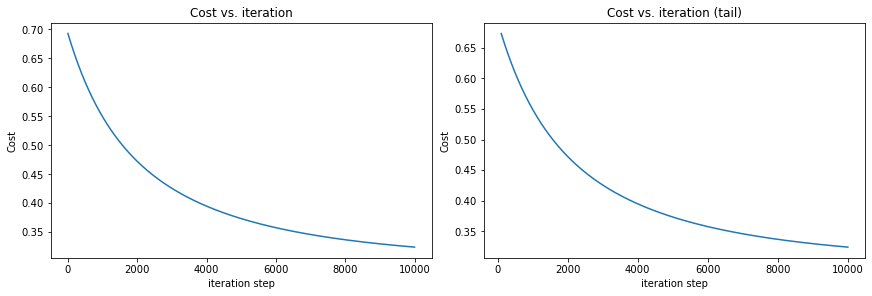

In [12]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()